In [21]:
import subprocess
subprocess.run(["pip", "install", "astroquery", "astropy", "matplotlib", "pandas", "scikit-learn"], 
               capture_output=True)
print("Tutto installato!")

Tutto installato!


Scarico galassie reali

In [40]:
from astroquery.sdss import SDSS
import pandas as pd
import matplotlib.pyplot as plt

# Query SQL diretta al database SDSS
# Chiedo 2000 galassie con i loro 5 colori + redshift
query = """
SELECT TOP 2000
    p.ra, p.dec,
    p.u, p.g, p.r, p.i, p.z,
    s.class, s.z as redshift
FROM PhotoObj p
JOIN SpecObj s ON s.bestobjid = p.objid
WHERE s.class = 'GALAXY'
  AND p.r BETWEEN 14 AND 19
  AND s.z BETWEEN 0.01 AND 0.3
"""

print("Scaricando galassie reali dall'SDSS... 🌌")
result = SDSS.query_sql(query)
df = result.to_pandas()

print(f"Galassie scaricate: {len(df)}")
print(df.head())

Scaricando galassie reali dall'SDSS... 🌌
Galassie scaricate: 2000
           ra       dec         u         g         r         i         z  \
0  196.554898 -0.664147  19.00659  17.46996  16.69207  16.29661  16.01036   
1  213.103751 -0.627614  21.35692  18.08822  17.08086  16.59038  16.29396   
2  213.101175 -0.732015  18.93977  17.90734  17.55563  17.28040  17.16805   
3  213.065007 -0.633023  17.28403  15.63975  14.72320  14.20372  13.77550   
4  212.999212 -0.813086  20.79153  18.82034  17.72871  17.25541  16.83757   

    class  redshift  
0  GALAXY  0.083987  
1  GALAXY  0.135717  
2  GALAXY  0.054416  
3  GALAXY  0.025591  
4  GALAXY  0.127084  


Prima visualizzazione

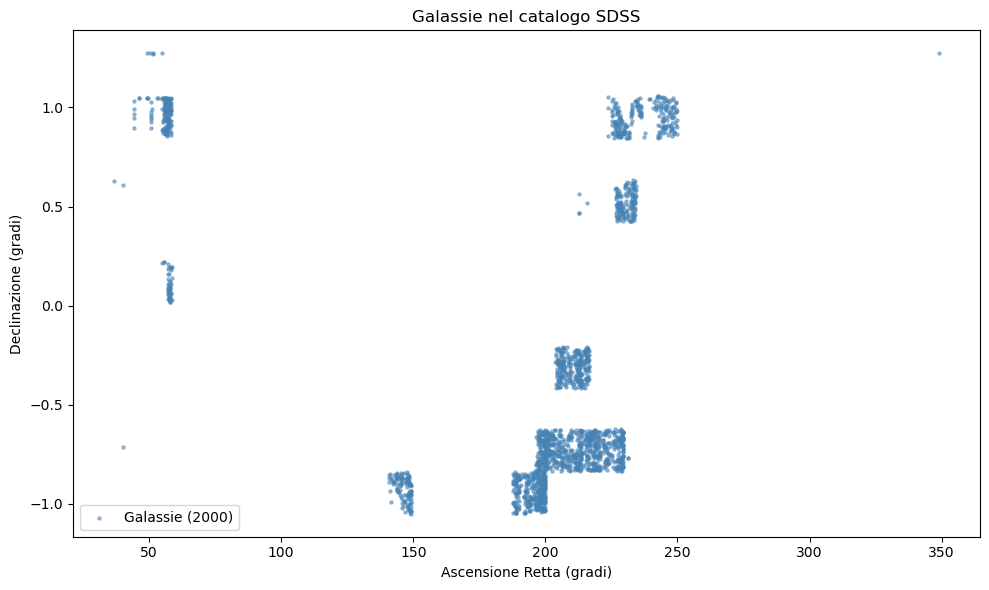

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(df['ra'], df['dec'], s=5, alpha=0.5, label=f'Galassie ({len(df)})', color='steelblue')

plt.xlabel('Ascensione Retta (gradi)')
plt.ylabel('Declinazione (gradi)')
plt.title('Galassie nel catalogo SDSS')
plt.legend()
plt.tight_layout()
plt.show()

Pulizia dei dati ed istogramma

Galassie prima della pulizia: 2000
Galassie dopo la pulizia:     1997


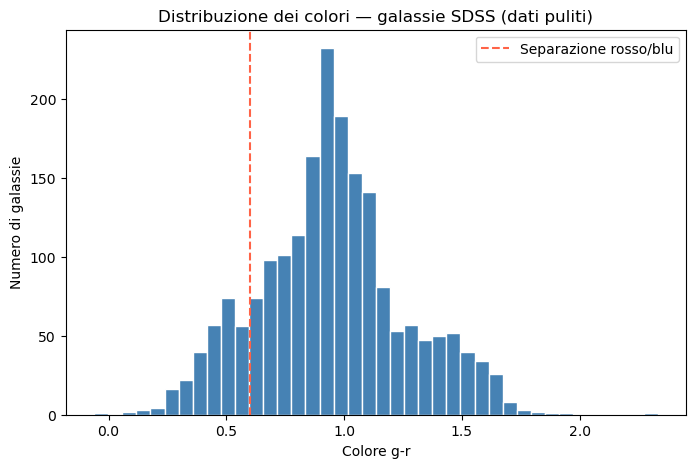

Galassie rosse (g-r > 0.6): 1719
Galassie blu  (g-r < 0.6): 278


In [29]:
# Rimuovo tutte le righe dove uno dei colori è -9999
df_clean = df[(df['u'] > -9998) & 
              (df['g'] > -9998) & 
              (df['r'] > -9998) & 
              (df['i'] > -9998) & 
              (df['z'] > -9998)]

print(f"Galassie prima della pulizia: {len(df)}")
print(f"Galassie dopo la pulizia:     {len(df_clean)}")

# Ricalcolo il colore sul dataset pulito
df_clean = df_clean.copy()
df_clean['colore_g_r'] = df_clean['g'] - df_clean['r']

#Istogramma
plt.figure(figsize=(8, 5))
plt.hist(df_clean['colore_g_r'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Colore g-r')
plt.ylabel('Numero di galassie')
plt.title('Distribuzione dei colori — galassie SDSS (dati puliti)')
plt.axvline(x=0.6, color='tomato', linestyle='--', label='Separazione rosso/blu')
plt.legend()
plt.show()

print(f"Galassie rosse (g-r > 0.6): {len(df_clean[df_clean['colore_g_r'] > 0.6])}")
print(f"Galassie blu  (g-r < 0.6): {len(df_clean[df_clean['colore_g_r'] < 0.6])}")

Scrittura e definizione del training model: Random Forest

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

X = df_clean[['u', 'g', 'r', 'i', 'z']]

y = (df_clean['colore_g_r'] > 0.6).astype(int)

print(f"Galassie rosse (etichetta 1): {y.sum()}")
print(f"Galassie blu  (etichetta 0): {(y==0).sum()}")

Galassie rosse (etichetta 1): 1719
Galassie blu  (etichetta 0): 278


Dividiamo i dati in training e test

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% dei dati va al test
    random_state=42     # numero fisso per riproducibilità
)

print(f"Galassie per addestrare il modello: {len(X_train)}")
print(f"Galassie per testare il modello:    {len(X_test)}")

Galassie per addestrare il modello: 1597
Galassie per testare il modello:    400


Alleniamo il modello

In [39]:
# Creo il modello
modello = RandomForestClassifier(
    n_estimators=100,   # userà 100 alberi decisionali
    random_state=42
)

modello.fit(X_train, y_train)

print(" Modello allenato!")

 Modello allenato!


Valutazione del modello

In [32]:
# Predizioni
y_pred = modello.predict(X_test)

print("=== PERFORMANCE DEL MODELLO ===\n")
print(classification_report(y_test, y_pred, 
      target_names=['Galassie blu', 'Galassie rosse']))

=== PERFORMANCE DEL MODELLO ===

                precision    recall  f1-score   support

  Galassie blu       0.96      0.90      0.93        59
Galassie rosse       0.98      0.99      0.99       341

      accuracy                           0.98       400
     macro avg       0.97      0.95      0.96       400
  weighted avg       0.98      0.98      0.98       400



In [33]:
from sklearn.model_selection import cross_val_score

# Ripeto la valutazione 5 volte con divisioni diverse
scores = cross_val_score(
    modello, X, y, 
    cv=5,           # 5 divisioni diverse
    scoring='accuracy'
)

print("Accuratezza per ogni fold:")
for i, s in enumerate(scores):
    print(f"  Fold {i+1}: {s:.4f}")

print(f"\nMedia:             {scores.mean():.4f}")
print(f"Deviazione standard: {scores.std():.4f}")
print(f"\nInterpretazione: il modello ha accuratezza {scores.mean()*100:.1f}% ± {scores.std()*100:.1f}%")

Accuratezza per ogni fold:
  Fold 1: 0.9825
  Fold 2: 0.9800
  Fold 3: 0.9774
  Fold 4: 0.9925
  Fold 5: 0.9825

Media:             0.9830
Deviazione standard: 0.0051

Interpretazione: il modello ha accuratezza 98.3% ± 0.5%


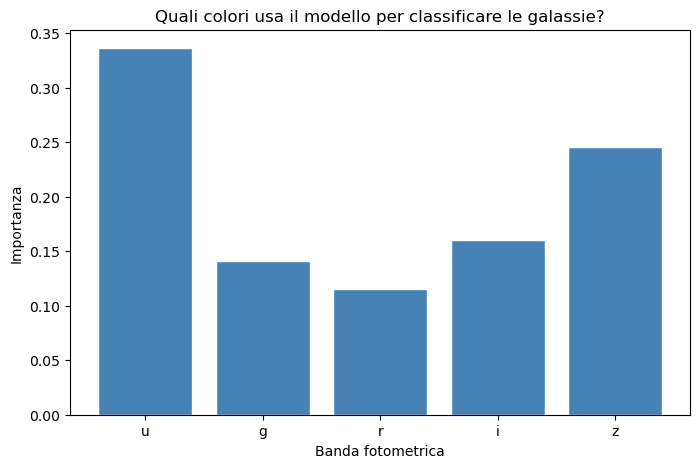

  u: 0.336
  z: 0.246
  i: 0.161
  g: 0.141
  r: 0.116


In [35]:
importanze = modello.feature_importances_
feature_names = ['u', 'g', 'r', 'i', 'z']

plt.figure(figsize=(8, 5))
plt.bar(feature_names, importanze, color='steelblue', edgecolor='white')
plt.xlabel('Banda fotometrica')
plt.ylabel('Importanza')
plt.title('Quali colori usa il modello per classificare le galassie?')
plt.show()

for nome, imp in sorted(zip(feature_names, importanze), 
                         key=lambda x: x[1], reverse=True):
    print(f"  {nome}: {imp:.3f}")

PCA (Principal Component Analysis

In [36]:
from sklearn.decomposition import PCA

#Comprimo 5 dimensioni in 2

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

print(f"Varianza spiegata dalle 2 componenti: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Varianza spiegata dalle 2 componenti: 99.2%


Allenamento del modello sullo spazio 2D

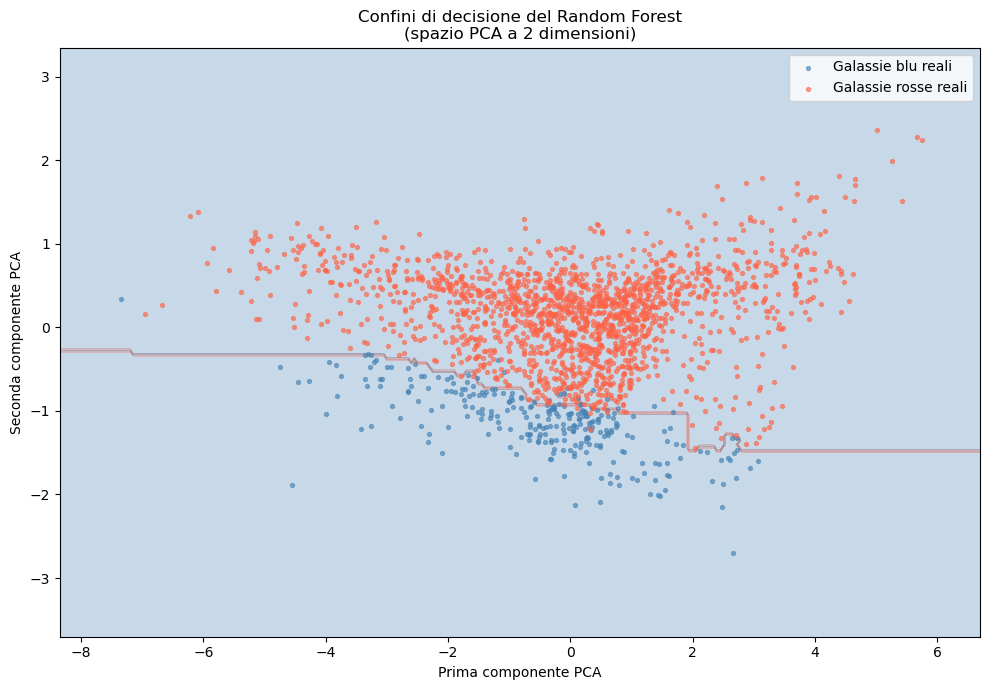

In [37]:
import numpy as np

modello_2d = RandomForestClassifier(n_estimators=100, random_state=42)
modello_2d.fit(X_2d, y)

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Per ogni punto della griglia: rossa o blu?
Z = modello_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 7))

# Coloro lo sfondo in base alla decisione del modello
plt.contourf(xx, yy, Z, alpha=0.3, 
             colors=['steelblue', 'tomato'])

# Sovrappongo le galassie reali
plt.scatter(X_2d[y==0, 0], X_2d[y==0, 1], 
            c='steelblue', s=8, alpha=0.6, label='Galassie blu reali')
plt.scatter(X_2d[y==1, 0], X_2d[y==1, 1], 
            c='tomato', s=8, alpha=0.6, label='Galassie rosse reali')

plt.xlabel('Prima componente PCA')
plt.ylabel('Seconda componente PCA')
plt.title('Confini di decisione del Random Forest\n(spazio PCA a 2 dimensioni)')
plt.legend()
plt.tight_layout()
plt.show()

Aggiunta del Redshift

In [38]:
# Nuovo dataset con redshift aggiunto
X_con_z = df_clean[['u', 'g', 'r', 'i', 'z', 'redshift']]

# Cross-validation con il redshift
scores_con_z = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_con_z, y, cv=5, scoring='accuracy'
)

print("=== CONFRONTO ===")
print(f"Senza redshift: {scores.mean()*100:.1f}% ± {scores.std()*100:.1f}%")
print(f"Con redshift:   {scores_con_z.mean()*100:.1f}% ± {scores_con_z.std()*100:.1f}%")

differenza = (scores_con_z.mean() - scores.mean()) * 100
if differenza > 0.2:
    print(f"\n Il redshift migliora il modello di {differenza:.1f}%")
elif differenza < -0.2:
    print(f"\n Il redshift peggiora il modello di {abs(differenza):.1f}%")
else:
    print(f"\n  Il redshift non cambia significativamente il modello")

=== CONFRONTO ===
Senza redshift: 98.3% ± 0.5%
Con redshift:   98.3% ± 0.5%

  Il redshift non cambia significativamente il modello
